# Notebook 04v2: Modeling: Disaster-Level Classification (DRF Scope)

## Overview

**OUR BUSINESS QUESTION Q1:** "at the exact moment of a federal declaration, which funding tier will this disaster ultimately reach?"

**Model scope (Disaster Relief Fund tiers only):**
* Tier 0: Minor (<$1M)
* Tier 1: Moderate ($1M to $50M)
* Tier 2: Major ($50M to $500M)

**Why Tier 3 (Catastrophic >$500M) is excluded:**
As explained previously (spoiler), FEMA's day-to-day operations are funded by the baseline Disaster Relief Fund (DRF). Catastrophic events (Tier 3) are outliers that go way beyond the standard DRF and automatically trigger Congressional Emergency Supplemental Appropriations, which is a completely separate funding mechanism, thus out of scope for our project. Including Tier 3 would generate false positives that incorrectly reserve DRF budget for rare events the fund was never designed to cover, harming planning accuracy for the core routine disasters.

In [1]:
#imports: data + viz + ml + pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
sys.path.append('../')
from utils import classification_metrics, DISASTER_LABELS

#sklearn: pipeline + preprocessing + models + evaluation
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.base import clone

PROCESSED = '../data/processed/'
#load cleaned disaster-level dataset -> output from nb02
disas = pd.read_csv(PROCESSED + 'cleaned_disaster_level.csv', low_memory=False)
print('Disaster-level shape:', disas.shape)
print('Target distribution:')
print(disas['funding_tier'].value_counts().sort_index())

Disaster-level shape: (1766, 21)
Target distribution:
funding_tier
0     145
1    1296
2     254
3      71
Name: count, dtype: int64


## 4.1 Define Features and Target

As previously mentioned, only features completely known at declaration time (Day 1) are included in the feature set:

Below, a little table of overview:

| Feature | Type | Available at declaration? |
|---|---|---|
| "incidentType" | Categorical | Yes (stated in declaration) |
| "stateAbbreviation" | Categorical | Yes (stated in declaration) |
| "incident_season" | Categorical | Yes (derived from incident start date) |
| "declaration_lag_days" | Numeric | Yes (time from incident start to declaration) |
| "incident_duration_days" | Numeric | Yes (most incidents end within days of declaration) |
| "n_counties" | Numeric | Yes (counties officially designated in declaration) |
| "prior_disasters_5yr" | Numeric | Yes (historical record, known in advance) |
| "population" | Numeric | Yes (Census data, static) |
| "median_income" | Numeric | Yes (Census data, static) |
| "poverty_rate" | Numeric | Yes (Census data, static) |
| "risk_score" | Numeric | Yes (NRI data, static) |

The feature "n_projects" is deliberately excluded as the total number of Public Assistance applications only becomes known 12 to 18 months after the declaration (so data leakage!!).

As justified, Tier 3 rows are excluded from the modeling scope, corresponding to about 71 events aka approximately 4% of the data, which belongs to the Congressional supplemental scope rather than the DRF.

In [2]:
#cat + num features available at declaration time only -> no post-event leakage
CAT_FEATURES = ['incidentType', 'stateAbbreviation', 'incident_season']
NUM_FEATURES = [
    'declaration_lag_days',
    'incident_duration_days',
    'n_counties',
    'prior_disasters_5yr',
    'population',
    'median_income',
    'poverty_rate',
    'risk_score',
]
TARGET = 'funding_tier'

#guard: only keep features that exist in the loaded dataframe
CAT_FEATURES = [c for c in CAT_FEATURES if c in disas.columns]
NUM_FEATURES = [c for c in NUM_FEATURES if c in disas.columns]
FEATURES     = CAT_FEATURES + NUM_FEATURES

#build model df: features + target + year, drop rows w/ missing target
df_model = disas[FEATURES + [TARGET, 'incident_year']].dropna(subset=[TARGET])
df_model[TARGET] = df_model[TARGET].astype(int)

#exclude tier 3 (catastrophic > $500m) -> funded by congressional supplemental, not drf
#including tier 3 -> false positives that misallocate drf budget
tier3_count = (df_model[TARGET] == 3).sum()
df_model = df_model[df_model[TARGET] <= 2].copy()
print(f'Tier 3 rows excluded (Congressional supplemental scope): {tier3_count}')

print(f'Modeling rows: {len(df_model):,}  |  Features: {len(FEATURES)}')
print('Categorical:', CAT_FEATURES)
print('Numeric:    ', NUM_FEATURES)
print('\nClass distribution (DRF tiers only):')
for t, n in df_model[TARGET].value_counts().sort_index().items():
    print(f'  Tier {t}  {DISASTER_LABELS[t]:<28}  {n:>5,}  ({100*n/len(df_model):.1f}%)')

Tier 3 rows excluded (Congressional supplemental scope): 71
Modeling rows: 1,695  |  Features: 11
Categorical: ['incidentType', 'stateAbbreviation', 'incident_season']
Numeric:     ['declaration_lag_days', 'incident_duration_days', 'n_counties', 'prior_disasters_5yr', 'population', 'median_income', 'poverty_rate', 'risk_score']

Class distribution (DRF tiers only):
  Tier 0  Minor (<$1M)                    145  (8.6%)
  Tier 1  Moderate ($1M–$50M)           1,296  (76.5%)
  Tier 2  Major ($50M–$500M)              254  (15.0%)


## 4.2 Three-Way Temporal Train / Validation / Test Split

We discussed extensively on how to split the data and reached the following conclusion: a standard random split would allow the model to train on a 2020 disaster and test on a 2005 disaster, so leaking future meteorological and bureaucratic patterns into the training phase. So, to ensure validity we opted for a temporal split to order the data by time, simulating the real-world deployment of the model.

Another little table of recap:

| Set | Years | Purpose |
|---|---|---|
| **Train** | pre-2016 | Fit all algorithms |
| **Validation** | 2016 to 2017 | Select the best performing model (never used to fit) |
| **Test** | 2018+ | Final reported metrics (touched exactly once at the end) |

In [3]:
#temporal split -> prevents training on future data
#train: pre-2016 | val: 2016-2017 (model selection only) | test: 2018+ (final reporting)
VALIDATION_YEAR = 2016
SPLIT_YEAR      = 2018

train = df_model[df_model['incident_year'] <  VALIDATION_YEAR]
val   = df_model[(df_model['incident_year'] >= VALIDATION_YEAR) &
                 (df_model['incident_year'] <  SPLIT_YEAR)]
test  = df_model[df_model['incident_year'] >= SPLIT_YEAR]

#separate features vs target for each split
X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train : {len(X_train):,}  ({train["incident_year"].min()}–{train["incident_year"].max()})')
print(f'Val   : {len(X_val):,}    ({val["incident_year"].min()}–{val["incident_year"].max()})')
print(f'Test  : {len(X_test):,}   ({test["incident_year"].min()}–{test["incident_year"].max()})')

Train : 1,085  (1998–2015)
Val   : 92    (2016–2017)
Test  : 518   (2018–2026)


## 4.3 Preprocessing Pipeline

All preprocessing steps are wrapped in the "pipeline" below to ensure the exact same transformations apply consistently to the train, validation, and test sets, and prevents information from the validation or test sets from influencing the fitted transformers (like the standard scaler).

* **Categorical:**  we impute missing values with "Unknown" and apply one-hot encoding.
* **Numeric:** we impute missing values with the median and standardize to a zero mean and unit variance.

In [4]:
#cat pipeline: fill missing w/ 'unknown' -> one-hot encode (unknown cats ignored at test time)
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
#num pipeline: fill missing w/ median -> standardise (mean=0, std=1)
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])
#combine cat + num into columntransformer -> consistent transforms across train/val/test
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, CAT_FEATURES),
    ('num', num_pipe, NUM_FEATURES)
])
print('Preprocessor defined.')

Preprocessor defined.


## 4.4 Train and Evaluate Four Models

We train and evaluate 4 algorithms to establish baselines and try to capture both linear and non-linear patterns:

* **Stratified Baseline:** setting the mathematical baseline that any real machine learning model must beat to prove it is actually learning.
* **Logistic Regression:** our linear benchmark that provides the interpretable coefficients.
* **Random Forest:** our trusted ensemble of decision trees to handle non-linearity. Class imbalance is handled via the "class_weight='balanced'" parameter.
* **Gradient Boosting:** our sequential tree ensemble.

Each model is evaluated on the validation set for selection purposes, and the test set for final reporting.

In [5]:
#target names for drf tiers 0, 1, 2 only
TARGET_NAMES = [DISASTER_LABELS[i] for i in range(3)]

#4 models: dummy baseline + lr + rf + gb
#class_weight='balanced' -> down-weights tier 1 majority (76%) + up-weights tier 0/2 minority
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression':   LogisticRegression(max_iter=1000, class_weight='balanced',
                                                random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results_val      = {}   #val metrics -> used for model selection only
results_disaster = {}   #test metrics -> final reporting only, touched once

for name, model in models.items():
    #wrap preprocessor + model in pipeline -> no val/test data leaks into fitted transformers
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    #val predictions -> model selection
    val_preds  = pipe.predict(X_val)
    m_val      = classification_metrics(y_val.values, val_preds, label=name,
                                        target_names=TARGET_NAMES)
    results_val[name] = {**m_val, 'pipeline': pipe, 'preds': val_preds}

    #test predictions -> stored but not used for selection
    test_preds = pipe.predict(X_test)
    m_test     = classification_metrics(y_test.values, test_preds, label=name,
                                        target_names=TARGET_NAMES)
    m_test['pipeline'] = pipe
    m_test['preds']    = test_preds
    results_disaster[name] = m_test

    print(f'{name:<30}  val F1={m_val["F1_weighted"]:.4f}  |  test F1={m_test["F1_weighted"]:.4f}')


  Baseline (Stratified)
  Accuracy   :   0.6957
  F1 (wtd)   :   0.6774

                     precision    recall  f1-score   support

       Minor (<$1M)       0.00      0.00      0.00         4
Moderate ($1M–$50M)       0.77      0.86      0.81        69
 Major ($50M–$500M)       0.50      0.26      0.34        19

           accuracy                           0.70        92
          macro avg       0.42      0.37      0.38        92
       weighted avg       0.68      0.70      0.68        92


  Baseline (Stratified)
  Accuracy   :   0.5695
  F1 (wtd)   :   0.5189

                     precision    recall  f1-score   support

       Minor (<$1M)       0.04      0.01      0.02        76
Moderate ($1M–$50M)       0.66      0.82      0.73       340
 Major ($50M–$500M)       0.21      0.15      0.17       102

           accuracy                           0.57       518
          macro avg       0.30      0.33      0.31       518
       weighted avg       0.48      0.57      0.52    

## 4.5 Hyperparameter Tuning — Gradient Boosting (Challenger Validation)

Logistic Regression leads after the initial four-model comparison. However, before accepting this result, we actively tune the Gradient Boosting model to serve as a challenger to check whether it's a matter of unoptimized params.

The default Gradient Boosting params showed clear signs of overfitting. We noticed how the algorithm built overly deep trees that memorized the training data instead of learning a generalizable signal. To correct this, we set the hyperparameter search grid to try to constrain model complexity by forcing shallower trees and heavier leaves.

We use "RandomizedSearchCV" to test 30 random parameter combinations. The cross-validation process uses a "TimeSeriesSplit(n_splits=5)". This guarantees that even the internal validation folds respect chronological order, preventing any future meteorological or administrative data from leaking into the training step.

In [6]:
#timeseriessplit -> internal cv folds respect temporal order within training set
tscv = TimeSeriesSplit(n_splits=5)

#original grid (commented out) -> replaced w/ regularised grid to reduce overfit
#param_dist = {
#    'model__n_estimators':      [100, 200, 300, 400],
#    'model__max_depth':         [3, 4, 5, 6],
#    'model__learning_rate':     [0.05, 0.1, 0.15, 0.2],
#    'model__min_samples_split': [2, 5, 10],
#    'model__subsample':         [0.7, 0.8, 1.0],
#}

param_dist = {
    #shallower trees: depth 2-3 vs default 3-6 -> reduces overfit
    'model__max_depth': [2, 3],
    #heavier leaves: min 10-20 disasters per leaf -> prevents rules from single outliers
    'model__min_samples_leaf': [10, 15, 20],
    #high split threshold: 30-50 samples needed to attempt a split
    'model__min_samples_split': [30, 40, 50],
    #subsample 60-70% of data per tree -> adds randomness + reduces fixation on specific rows
    'model__subsample': [0.6, 0.7, 0.8],
    #shallow trees + lower lr -> more trees needed to compensate
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300]
}

gb_base_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', GradientBoostingClassifier(random_state=42))
])

#randomizedsearchcv: 30 random combos -> faster than gridsearch w/ comparable coverage
search = RandomizedSearchCV(
    gb_base_pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print('\nBest params:', search.best_params_)
print(f'Best CV F1 (train folds): {search.best_score_:.4f}')

#val predictions -> model selection
tuned_val_preds = search.best_estimator_.predict(X_val)
m_tuned_val = classification_metrics(y_val.values, tuned_val_preds,
                                      label='GradBoosting (Tuned)',
                                      target_names=TARGET_NAMES)
results_val['GradBoosting (Tuned)'] = {
    **m_tuned_val, 'pipeline': search.best_estimator_, 'preds': tuned_val_preds
}

#test predictions -> final reporting only
tuned_test_preds = search.best_estimator_.predict(X_test)
m_tuned_test = classification_metrics(y_test.values, tuned_test_preds,
                                       label='GradBoosting (Tuned)',
                                       target_names=TARGET_NAMES)
m_tuned_test['pipeline'] = search.best_estimator_
m_tuned_test['preds']    = tuned_test_preds
results_disaster['GradBoosting (Tuned)'] = m_tuned_test

print(f'\nTuned — Val  F1_weighted: {m_tuned_val["F1_weighted"]:.4f}')
print(f'Tuned — Test F1_weighted: {m_tuned_test["F1_weighted"]:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'model__subsample': 0.6, 'model__n_estimators': 200, 'model__min_samples_split': 40, 'model__min_samples_leaf': 20, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best CV F1 (train folds): 0.8241

  GradBoosting (Tuned)
  Accuracy   :   0.8043
  F1 (wtd)   :   0.7720

                     precision    recall  f1-score   support

       Minor (<$1M)       0.75      0.75      0.75         4
Moderate ($1M–$50M)       0.81      0.96      0.88        69
 Major ($50M–$500M)       0.71      0.26      0.38        19

           accuracy                           0.80        92
          macro avg       0.76      0.66      0.67        92
       weighted avg       0.79      0.80      0.77        92


  GradBoosting (Tuned)
  Accuracy   :   0.7259
  F1 (wtd)   :   0.6833

                     precision    recall  f1-score   support

       Minor (<$1M)       0.66      0.63      0.64        76
Moderate ($1M–$50M)    

## 4.6 Bootstrap Stability Analysis

Given the split we chose for training, with a bit over 1K rows, a single train/test split produces a point estimate of the F1 score that may be heavily influenced by luck. For this, we resorted to bootstrap resampling to quantify exactly how stable the model's performance is.

**Methodology:** we resample the training set with replacement 50 times, refit the validation-selected best model on each unique resample, and evaluate it on the same fixed test set. The output is a mean score with a 95% confidence interval. A tight confidence interval confirms the model's predictive power is quite sound and not a fluke of one specific data split.

Bootstrapping: Logistic Regression

Bootstrap F1_weighted over 50 resamples:
  Mean  : 0.6793
  Std   : 0.0140
  95% CI: [0.6535,  0.7059]


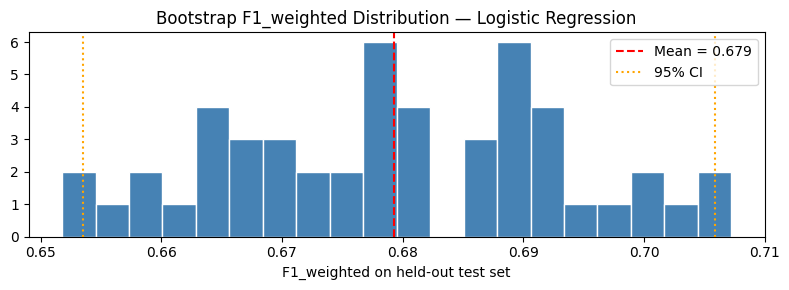

In [7]:
N_BOOTSTRAP = 50
rng = np.random.default_rng(42)
bootstrap_f1 = []

#select best model by val f1 -> same pipeline bootstrapped throughout
best_name_boot = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
best_pipe_boot = results_val[best_name_boot]['pipeline']
print(f'Bootstrapping: {best_name_boot}')

for _ in range(N_BOOTSTRAP):
    #resample train set w/ replacement -> ~63% unique rows per boot sample
    idx      = rng.choice(len(X_train), size=len(X_train), replace=True)
    X_boot   = X_train.iloc[idx]
    y_boot   = y_train.iloc[idx]
    #clone -> fresh unfitted copy of pipeline (avoids state contamination between iterations)
    pipe_b   = clone(best_pipe_boot)
    pipe_b.fit(X_boot, y_boot)
    preds_b  = pipe_b.predict(X_test)
    #evaluate on same fixed test set -> isolates train sampling variance from test variance
    bootstrap_f1.append(f1_score(y_test, preds_b, average='weighted', zero_division=0))

bootstrap_f1 = np.array(bootstrap_f1)
print(f'\nBootstrap F1_weighted over {N_BOOTSTRAP} resamples:')
print(f'  Mean  : {bootstrap_f1.mean():.4f}')
print(f'  Std   : {bootstrap_f1.std():.4f}')
print(f'  95% CI: [{np.percentile(bootstrap_f1, 2.5):.4f},  {np.percentile(bootstrap_f1, 97.5):.4f}]')

#plot bootstrap f1 distribution -> tight ci confirms result is not a fluke of one split
plt.figure(figsize=(8, 3))
plt.hist(bootstrap_f1, bins=20, color='steelblue', edgecolor='white')
plt.axvline(bootstrap_f1.mean(), color='red', linestyle='--',
            label=f'Mean = {bootstrap_f1.mean():.3f}')
plt.axvline(np.percentile(bootstrap_f1, 2.5),  color='orange', linestyle=':', label='95% CI')
plt.axvline(np.percentile(bootstrap_f1, 97.5), color='orange', linestyle=':')
plt.title(f'Bootstrap F1_weighted Distribution — {best_name_boot}')
plt.xlabel('F1_weighted on held-out test set')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/bootstrap_f1_disaster.png', dpi=150)
plt.show()

## 4.7 Results Summary Table and Per-Class Breakdown

Model selection is strictly based on the Validation F1 score (the 2016 to 2017 holdout data). The Test F1 score (2018 onwards) is reported here for the final evaluation.

The per-class breakdown is highly important for our business problem. Specifically, the recall metric for Tier 2 (Major) shows how often the model correctly flags the highest-cost DRF events on Day 1. This is the most consequential tier for FEMA. An under-prediction (a false negative) on a Tier 2 disaster means FEMA will under-reserve capital from its baseline fund, potentially causing liquidity issues.

In [8]:
#overall f1 summary: val f1 used for selection, test f1 for final reporting
summary = pd.DataFrame([
    {
        'Model':    name,
        'Val F1':   round(results_val[name]['F1_weighted'], 4) if name in results_val else '-',
        'Test F1':  round(results_disaster[name]['F1_weighted'], 4),
        'Test Acc': round(results_disaster[name]['Accuracy'], 4),
    }
    for name in results_disaster
]).set_index('Model')
display(summary)

#per-class breakdown for best model (selected by val f1 only)
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'\nBest model (by val F1): {best_name}')
print(f'Per-class report on test set:')
#output_dict=True -> convert to df for cleaner display
report_df = pd.DataFrame(
    classification_report(
        y_test,
        results_disaster[best_name]['preds'],
        target_names=TARGET_NAMES,
        zero_division=0,
        output_dict=True
    )
).T.round(3)
display(report_df)

,Val F1,Test F1,Test Acc
Model,,,
Baseline (Stratified),0.6774,0.5189,0.5695
Logistic Regression,0.7859,0.6903,0.6853
Random Forest,0.7407,0.5593,0.6699
Gradient Boosting,0.7626,0.6750,0.7124
GradBoosting (Tuned),0.7720,0.6833,0.7259



Best model (by val F1): Logistic Regression
Per-class report on test set:


,precision,recall,f1-score,support
Minor (<$1M),0.438,0.645,0.521,76.000
Moderate ($1M–$50M),0.803,0.756,0.779,340.000
Major ($50M–$500M),0.570,0.480,0.521,102.000
accuracy,0.685,0.685,0.685,0.685
macro avg,0.603,0.627,0.607,518.000
weighted avg,0.704,0.685,0.690,518.000


## 4.8 Feature Importances and Confusion Matrix

**Feature importances** display which inputs drive the model's predictions the most. This acts as a construct validity check, ensuring the algorithm is learning from relevant signals (like incident type and affected counties) rather than mathematical noise.

**The confusion matrix** visualizes exactly where the classification errors occur. In this specific business context, adjacent-tier errors (such as predicting Moderate when the true cost is Major) are somewhat acceptable for early planning (to be adjusted as project proposals are approved), although we recognize this as a limitation to the prediction. However, cross-tier errors (such as predicting Minor when the true cost is Major) represent the costliest planning failures and require careful monitoring.

Logistic Regression does not expose feature_importances_ — skipping plot.


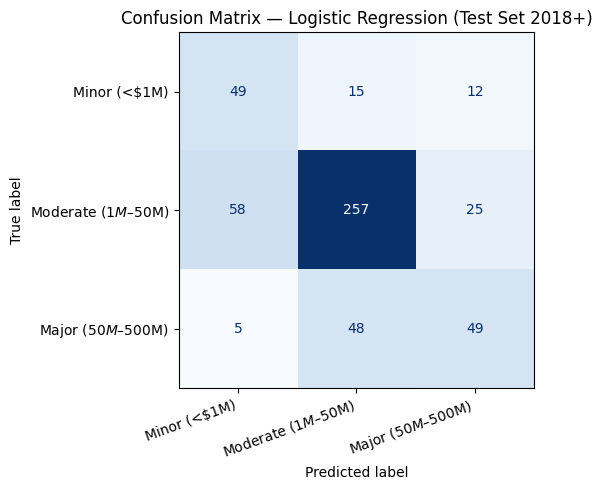

In [9]:
#select best model by val f1 -> extract pipeline components for plotting
best_name  = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
best_pipe  = results_disaster[best_name]['pipeline']
best_model = best_pipe.named_steps['model']
best_pre   = best_pipe.named_steps['pre']

#reconstruct feature names: ohe-expanded cat names + original numeric names
ohe_names = best_pre.transformers_[0][1].named_steps['ohe'].get_feature_names_out(CAT_FEATURES)
all_names  = list(ohe_names) + NUM_FEATURES

#feature importances: rf + gb expose feature_importances_, lr does not -> skip if unavailable
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=all_names)
    importances.nlargest(20).sort_values().plot(
        kind='barh', figsize=(10, 6),
        title=f'Top 20 Feature Importances — {best_name}',
        color='steelblue'
    )
    plt.tight_layout()
    plt.savefig('../data/processed/feature_importance_disaster.png', dpi=150)
    plt.show()
else:
    print(f'{best_name} does not expose feature_importances_ — skipping plot.')

#confusion matrix on test set -> adjacent-tier errors vs extreme-jump errors
cm = confusion_matrix(y_test, results_disaster[best_name]['preds'])
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (Test Set 2018+)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_disaster.png', dpi=150)
plt.show()

## 4.9 Save Best Pipeline

The final model, selected entirely by its performance on the validation set, is saved as a pickle bundle. This file contains the fitted pipeline, the test features, and the test predictions, allowing the final evaluation notebook (Notebook 06) to generate visual outputs without needing to re-run the training process.

In [10]:
#select best model by val f1 -> save pkl bundle for nb06
best_name = max(results_val, key=lambda k: results_val[k]['F1_weighted'])
print(f'Best model (val F1):   {best_name}')
print(f'  Val  F1_weighted : {results_val[best_name]["F1_weighted"]:.4f}')
print(f'  Test F1_weighted : {results_disaster[best_name]["F1_weighted"]:.4f}')

best_pipeline = results_disaster[best_name]['pipeline']

#save full bundle: pipeline + precomputed predictions + metadata
#nb06 loads this directly -> no retraining needed
with open(PROCESSED + 'best_disaster_model.pkl', 'wb') as f:
    pickle.dump({
        'pipeline':     best_pipeline,
        'proba':        best_pipeline.predict_proba(X_test),   #precomputed -> avoids calling pipeline in nb06
        'X_test':       X_test,
        'y_test':       y_test,
        'preds':        results_disaster[best_name]['preds'],
        'val_f1':       results_val[best_name]['F1_weighted'],
        'test_f1':      results_disaster[best_name]['F1_weighted'],
        'features':     FEATURES,
        'cat_features': CAT_FEATURES,
        'num_features': NUM_FEATURES,
        'target_names': TARGET_NAMES,
        'model_name':   best_name,
        'level':        'disaster',
    }, f)
print('Saved: best_disaster_model.pkl')

Best model (val F1):   Logistic Regression
  Val  F1_weighted : 0.7859
  Test F1_weighted : 0.6903
Saved: best_disaster_model.pkl
